<div align="center">
  <h2>
     <a href="https://github.com/rihab-l/Techniques-IA-TPs.git">
    Accéder au Notebook sur GitHub
    </a>
  </h2>
</div>

##  Introduction

Dans de nombreux problèmes réels, les données ne sont pas linéairement séparables.
Les modèles linéaires simples échouent souvent à capturer ces relations complexes.

Le dataset "make_moons" est un exemple classique de données non linéaires,
où les classes sont en forme de croissants.

En ajoutant du bruit, nous rendons le problème plus réaliste et plus difficile,
ce qui permet de tester la robustesse des modèles de Machine Learning.

## Objectif

L'objectif de cette étape est de générer un dataset synthétique non linéaire et bruité,
afin de simuler un problème de classification complexe.

Nous cherchons à :
- Comprendre la nature non linéaire des données
- Observer l’impact du bruit sur la séparation des classes
- Préparer le terrain pour l’utilisation de modèles non linéaires

## 1. Génération et Visualisation des Données Non Linéaires (make_moons)

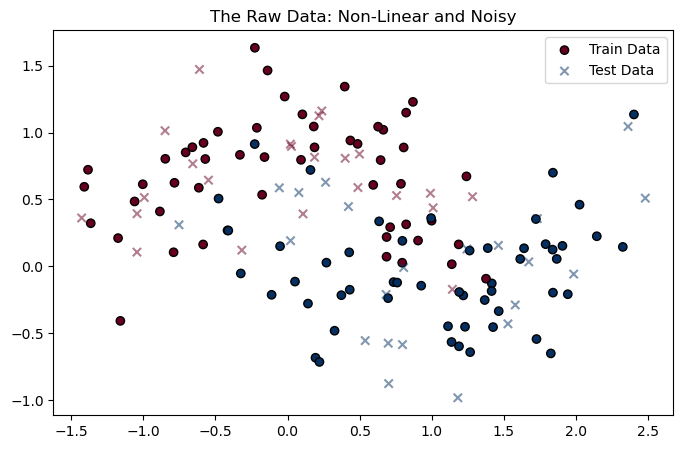

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate noisy data
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Plot the raw data
plt.figure(figsize=(8, 5))

plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')

plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')

plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

## 2. Modélisation Polynomiale Sans Régularisation (Risque de Surapprentissage)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

#  Modèle sans régularisation
model_lin = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lin_reg", LinearRegression())
])

#  Entraînement
model_lin.fit(X_train, y_train)

#  Prédiction
y_pred_cont = model_lin.predict(X_test)
y_pred = (y_pred_cont >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7333333333333333


## 3. Visualisation de la Frontière de Décision (Modèle Sans Régularisation)

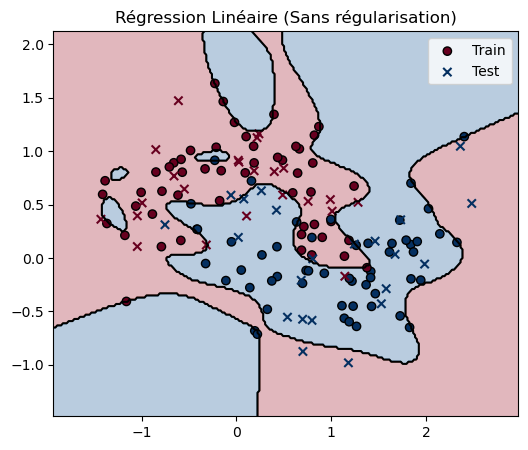

In [7]:
# Grille
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prédiction sur la grille
Z_cont = model_lin.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z_cont >= 0.5).astype(int)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.contour(xx, yy, Z, levels=[0.5], colors='black')

plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, cmap='RdBu', edgecolors='k', label='Train')

plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_test, cmap='RdBu', marker='x', label='Test')

plt.title("Régression Linéaire (Sans régularisation)")
plt.legend()
plt.show()

## 4. Modélisation Polynomiale avec Régularisation L1 (Lasso)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import accuracy_score

# 🔹 Modèle L1
model_l1 = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.05))
])

# 🔹 Entraînement
model_l1.fit(X_train, y_train)

# 🔹 Prédiction
y_pred_cont = model_l1.predict(X_test)
y_pred = (y_pred_cont >= 0.5).astype(int)

print("Accuracy L1:", accuracy_score(y_test, y_pred))

Accuracy L1: 0.8444444444444444


## 5. Visualisation de la Frontière de Décision avec Régularisation L1 (Lasso)

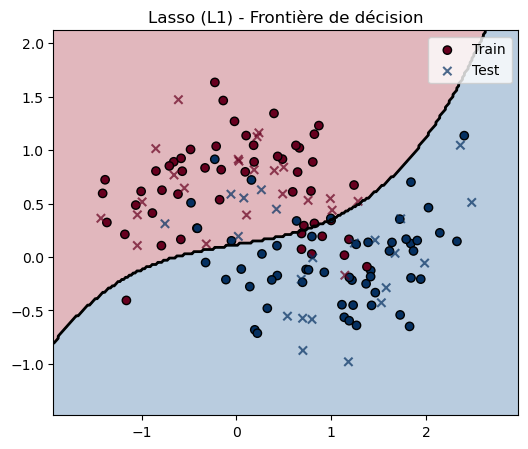

In [9]:
# Grille
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prédiction
Z_cont = model_l1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z_cont >= 0.5).astype(int)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, cmap='RdBu', edgecolors='k', label='Train')

plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_test, cmap='RdBu', marker='x', alpha=0.7, label='Test')

plt.title("Lasso (L1) - Frontière de décision")
plt.legend()
plt.show()

## 6. Modélisation Polynomiale avec Régularisation L2 (Ridge)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score

# Modèle L2 (Ridge)
model_l2 = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Entraînement
model_l2.fit(X_train, y_train)

# Prédiction (conversion en classification)
y_pred_cont = model_l2.predict(X_test)
y_pred = (y_pred_cont >= 0.5).astype(int)

print("Accuracy L2 :", accuracy_score(y_test, y_pred))

Accuracy L2 : 0.8444444444444444


## 7. Visualisation de la Frontière de Décision avec Régularisation L2 (Ridge)

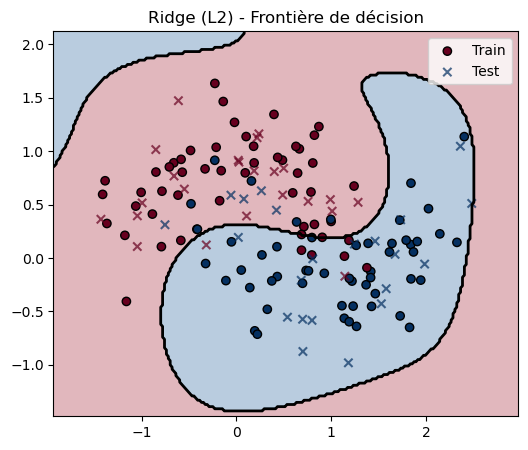

In [11]:
# Grille
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prédiction sur la grille
Z_cont = model_l2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z_cont >= 0.5).astype(int)
Z = Z.reshape(xx.shape)

# Affichage
plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, cmap='RdBu', edgecolors='k', label='Train')

plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_test, cmap='RdBu', marker='x', alpha=0.7, label='Test')

plt.title("Ridge (L2) - Frontière de décision")
plt.legend()
plt.show()

## 8. Comparaison des Modèles Polynomiaux avec et sans Régularisation selon le Degré

In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import accuracy_score

#  1. Générer les données
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=20,
    n_redundant=10,
    random_state=42
)

#  2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#  3. Degrés à tester
degrees = [2,3]

#  4. Modèles
models = {
    "Sans régularisation": LinearRegression(),
    "L1 (Lasso)": Lasso(alpha=0.01, max_iter=5000),
    "L2 (Ridge)": Ridge(alpha=1.0)
}

#  5. Boucle principale
results = []

for deg in degrees:
    print(f"\n===== DEGREE = {deg} =====")
    
    for name, model in models.items():
        
        # Pipeline
        pipe = Pipeline([
            ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        
        # Entraînement
        pipe.fit(X_train, y_train)
        
        # Prédiction
        y_pred_cont = pipe.predict(X_test)
        y_pred = (y_pred_cont >= 0.5).astype(int)
        
        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        
        print(f"{name} → Accuracy: {acc:.4f}")
        
        results.append({
            "degree": deg,
            "model": name,
            "accuracy": acc
        })

#  6. Résumé sous forme de tableau
df_results = pd.DataFrame(results)
print("\nRésumé :")
print(df_results)


===== DEGREE = 2 =====
Sans régularisation → Accuracy: 0.8822
L1 (Lasso) → Accuracy: 0.9456
L2 (Ridge) → Accuracy: 0.8944

===== DEGREE = 3 =====
Sans régularisation → Accuracy: 0.8900
L1 (Lasso) → Accuracy: 0.9422
L2 (Ridge) → Accuracy: 0.8900

Résumé :
   degree                model  accuracy
0       2  Sans régularisation  0.882222
1       2           L1 (Lasso)  0.945556
2       2           L2 (Ridge)  0.894444
3       3  Sans régularisation  0.890000
4       3           L1 (Lasso)  0.942222
5       3           L2 (Ridge)  0.890000


## 9. Analyse de l’Impact du Degré Polynomial sur la Performance des Modèles

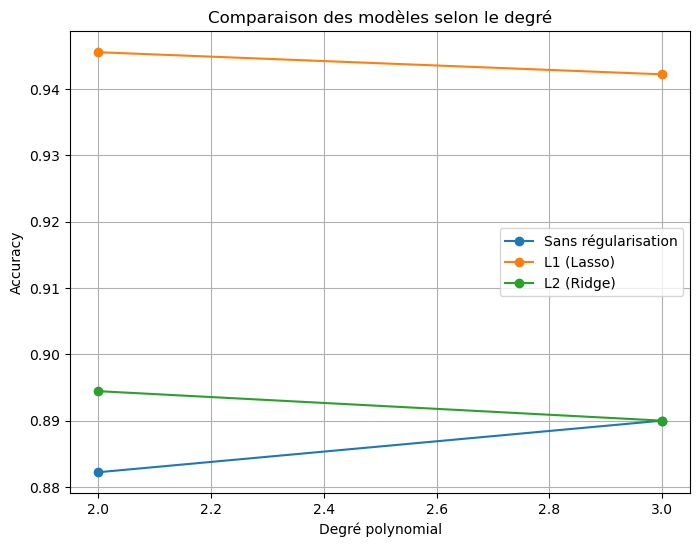

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Boucle sur chaque modèle
for model_name in df_results["model"].unique():
    subset = df_results[df_results["model"] == model_name]
    
    plt.plot(subset["degree"], subset["accuracy"], marker='o', label=model_name)

plt.xlabel("Degré polynomial")
plt.ylabel("Accuracy")
plt.title("Comparaison des modèles selon le degré")
plt.legend()
plt.grid()

plt.show()

## 10. Comparaison des Frontières de Décision pour Différents Modèles et Degrés Polynomiaux

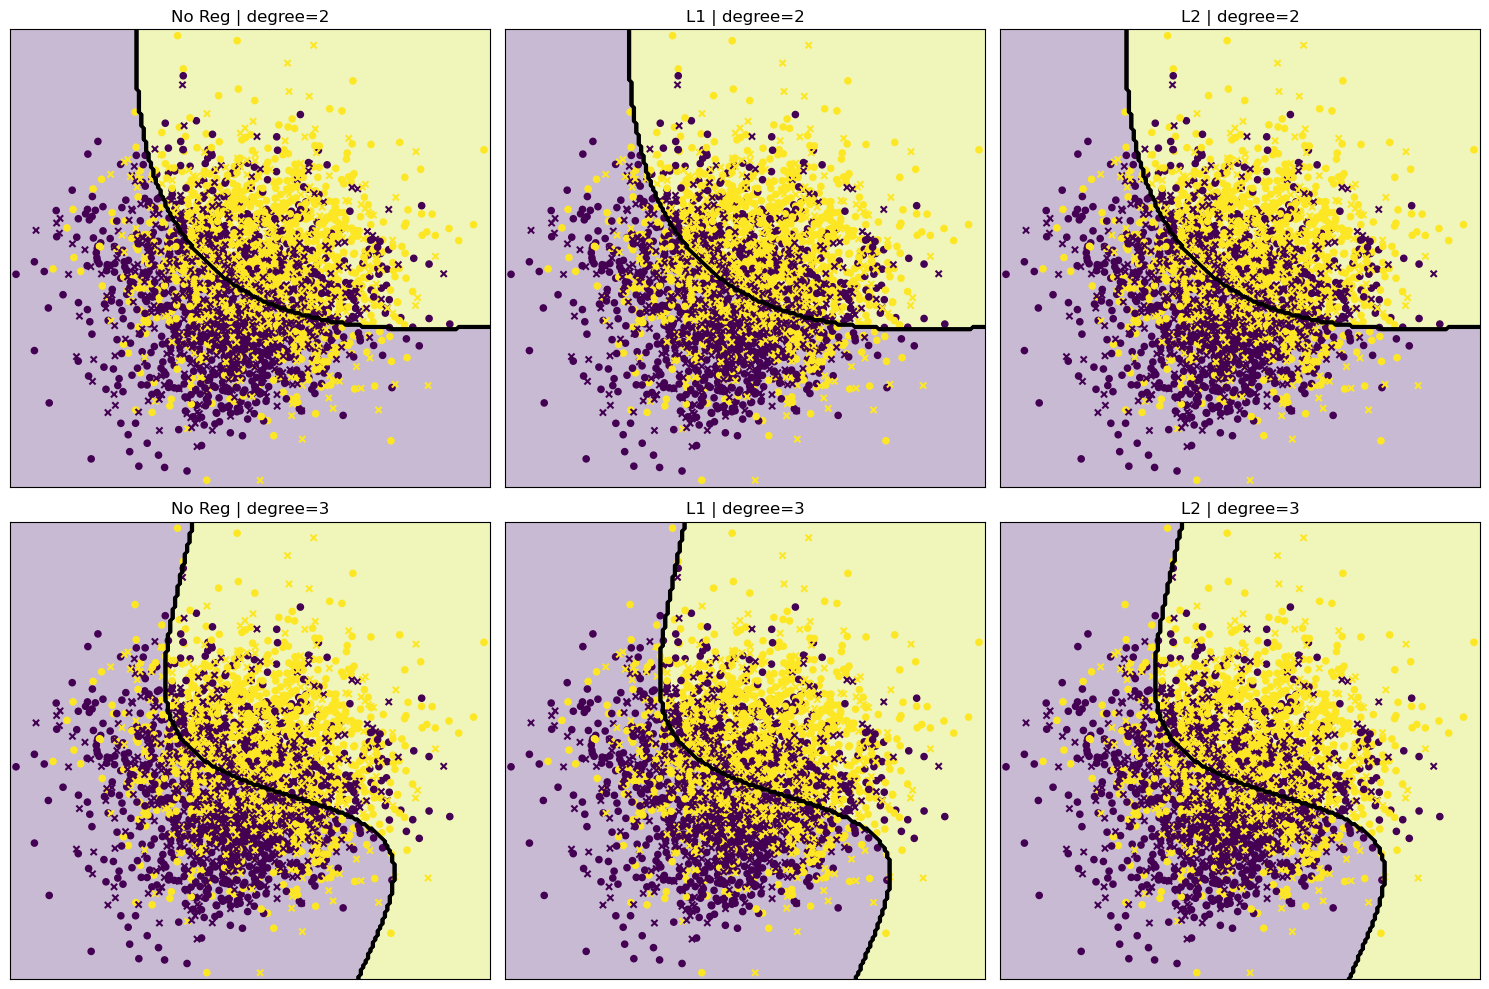

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

# PCA → 2D pour visualisation
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

#  modèles
models = {
    "No Reg": LogisticRegression(penalty=None, max_iter=2000),
    "L1": LogisticRegression(penalty="l1", solver="liblinear"),
    "L2": LogisticRegression(penalty="l2")
}

degrees = [2, 3]

#  grille
x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

#  FIGURE GRID
fig, axes = plt.subplots(len(degrees), len(models), figsize=(15,10))

for i, deg in enumerate(degrees):
    for j, (name, model) in enumerate(models.items()):
        
        # pipeline
        pipe = Pipeline([
            ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        
        # train
        pipe.fit(X_train_2D, y_train)
        
        # predict grid
        Z = pipe.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        ax = axes[i, j]
        
        # fond
        ax.contourf(xx, yy, Z, alpha=0.3)
        ax.contour(xx, yy, Z, colors='black')
        
        # points
        ax.scatter(X_train_2D[:,0], X_train_2D[:,1], c=y_train, marker='o', s=20)
        ax.scatter(X_test_2D[:,0], X_test_2D[:,1], c=y_test, marker='x', s=20)
        
        ax.set_title(f"{name} | degree={deg}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## Conclusion 
La combinaison de la transformation polynomiale et de la régularisation
est essentielle pour construire des modèles performants et robustes
face à des données complexes et bruitées.